In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat


Device: cuda
Global train min/max: min=-1.230065e-07, max=1.210273e-07
Training with DYNAMIC q-bits | epochs=200 | batch_size=256
Epoch 1/200 | lr=5.00e-05 | train_loss=1.8140e-01 | val_NMSE=11.535 dB | best=11.535 dB | t=5.6s
Epoch 10/200 | lr=6.35e-04 | train_loss=1.2606e-04 | val_NMSE=-13.756 dB | best=-13.756 dB | t=3.1s
Epoch 20/200 | lr=1.28e-03 | train_loss=5.2409e-05 | val_NMSE=-17.751 dB | best=-17.751 dB | t=3.2s
Epoch 30/200 | lr=1.94e-03 | train_loss=7.8555e-05 | val_NMSE=-18.583 dB | best=-18.583 dB | t=3.3s
Epoch 40/200 | lr=1.99e-03 | train_loss=4.8418e-05 | val_NMSE=-19.084 dB | best=-19.084 dB | t=3.3s
Epoch 50/200 | lr=1.94e-03 | train_loss=4.4648e-05 | val_NMSE=-16.178 dB | best=-19.666 dB | t=3.4s
Epoch 60/200 | lr=1.86e-03 | train_loss=3.5954e-05 | val_NMSE=-19.835 dB | best=-20.012 dB | t=3.5s
Epoch 70/200 | lr=1.76e-03 | train_loss=3.1436e-05 | val_NMSE=-19.995 dB | best=-20.456 dB | t=3.5s
Epoch 80/200 | lr=1.63e-03 | train_loss=2.7900e-05 | val_NMSE=-19.978 dB 

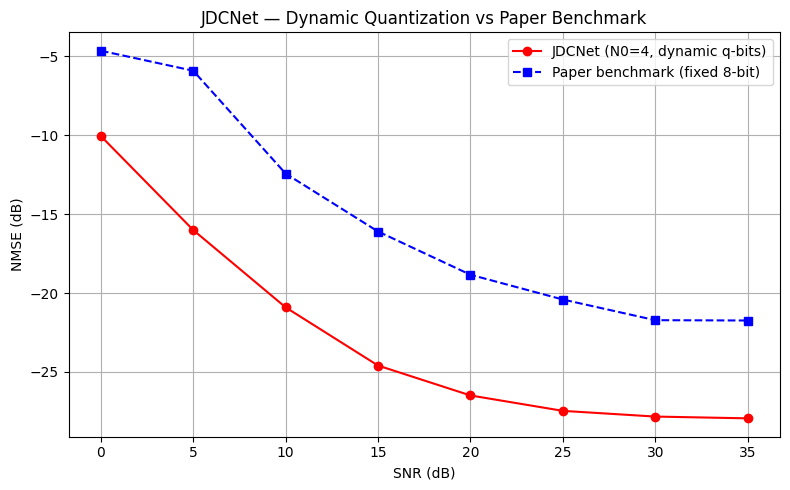

In [2]:
# jdcnet_dynamic_qbits.py
# JDCNet with DYNAMIC quantization bits based on channel SNR.
# Only change from original: snr_to_bits() + passing quant_bits dynamically
# during train, val, and test. No architecture changes.

import os, random, math, time, shutil
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------- reproducibility ----------------
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------ #
#  NEW: Dynamic quantization bit selector                             #
#  Low SNR  → fewer bits (noisy estimate, precision is wasted)        #
#  High SNR → more bits  (clean estimate, worth preserving detail)    #
#  Mapping  : SNR 0 dB  → min_bits (2)                               #
#             SNR 35 dB → max_bits (8)                               #
# ------------------------------------------------------------------ #
def snr_to_bits(snr_db, min_bits=2, max_bits=8, snr_min=0.0, snr_max=35.0):
    """Linearly map SNR (dB) to quantization bit-depth."""
    ratio = (snr_db - snr_min) / (snr_max - snr_min)
    ratio = max(0.0, min(1.0, ratio))           # clamp to [0,1]
    bits  = min_bits + (max_bits - min_bits) * ratio
    return int(round(bits))

# ---------------- flexible loader helper ----------------
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)

    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if 'model_state_dict' in sd:
            sd = sd['model_state_dict']
        elif 'state_dict' in sd:
            sd = sd['state_dict']

    if not isinstance(sd, dict):
        raise RuntimeError(f"Loaded object from {path} is not a state_dict mapping.")

    sd_keys = list(sd.keys())
    if len(sd_keys) == 0:
        raise RuntimeError("Loaded state_dict is empty")

    saved_has_module = sd_keys[0].startswith('module.')
    model_is_datapar = isinstance(model, nn.DataParallel)

    if verbose:
        print(f"[loader] Loaded state_dict from {path}. "
              f"saved_has_module={saved_has_module}, model_is_datapar={model_is_datapar}")

    if saved_has_module and not model_is_datapar:
        sd = {k[len('module.'):]: v for k, v in sd.items()}
        if verbose: print("[loader] Stripped 'module.' prefix from saved keys.")
    elif (not saved_has_module) and model_is_datapar:
        sd = {'module.' + k: v for k, v in sd.items()}
        if verbose: print("[loader] Added 'module.' prefix to saved keys to match DataParallel model.")

    try:
        model.load_state_dict(sd)
        if verbose: print("[loader] State dict loaded successfully (strict).")
    except Exception as e:
        if verbose:
            print("[loader] Strict load failed. Attempting non-strict load for diagnostics...")
        res = model.load_state_dict(sd, strict=False)
        if verbose:
            print("[loader] Non-strict load result:", res)
        raise e

# ---------------- STE Quantizer ----------------
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        levels    = 2 ** q_bits - 1
        x_clamped = torch.clamp(x, 0.0, 1.0)
        q         = torch.round(x_clamped * levels) / levels
        return q
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# ---------------- ResBlock (unchanged) ----------------
class PaperResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        identity = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + identity)

# ---------------- JDCNet (unchanged architecture) ----------------
class JDCNet_Paper(nn.Module):
    def __init__(self, M=16, N=64, N0=2, gamma=1/16, q_bits=8,
                 B=4, decoder_ch=16, quant_enabled=True):
        super().__init__()
        self.M, self.N, self.N0 = M, N, N0
        self.Np             = N // N0
        self.q_bits         = q_bits
        self.quant_enabled  = quant_enabled
        self.C              = int(gamma * 32 * N0)

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16,     kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, self.C, kernel_size=4, stride=2, padding=1)
        )

        self.decoder_tconv1 = nn.ConvTranspose2d(self.C, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)
        self.decoder_tconv2 = nn.ConvTranspose2d(decoder_ch, decoder_ch,
                                                  kernel_size=4, stride=2, padding=1)
        self.resblocks       = nn.Sequential(*[PaperResBlock(decoder_ch) for _ in range(B)])
        self.final_tconv     = nn.ConvTranspose2d(
            decoder_ch, decoder_ch,
            kernel_size=(1, 2 * N0), stride=(1, N0), padding=(0, N0 // 2)
        )
        self.final_conv      = nn.Conv2d(decoder_ch, 2, kernel_size=3, padding=1)

    def forward(self, x_norm, quant_bits=None):
        b       = x_norm.shape[0]
        z       = self.encoder(x_norm)
        z_shape = z.shape
        v       = z.view(b, -1)

        v_min = v.min(dim=1, keepdim=True)[0]
        v_max = v.max(dim=1, keepdim=True)[0]
        denom = (v_max - v_min).clamp_min(1e-12)

        if self.quant_enabled:
            # quant_bits is now supplied dynamically per batch/SNR
            qbits  = self.q_bits if quant_bits is None else quant_bits
            v_norm = (v - v_min) / denom
            v_q    = QuantizeSTE.apply(v_norm, qbits)
            v_deq  = v_q * denom + v_min
        else:
            v_deq = v

        z_deq = v_deq.view(*z_shape)
        y     = torch.relu(self.decoder_tconv1(z_deq))
        y     = torch.relu(self.decoder_tconv2(y))
        y     = self.resblocks(y)
        y     = torch.relu(self.final_tconv(y))
        out   = self.final_conv(y)
        return out

# ---------------- Dataset (unchanged) ----------------
class RISChannelDataset(Dataset):
    def __init__(self, mat_file, split='train'):
        data      = sio.loadmat(mat_file)
        H_mat     = np.transpose(data['H'], (2, 0, 1)).astype(np.complex64)
        G_mat     = np.transpose(data['G'], (2, 0, 1)).astype(np.complex64)
        H_cascade = G_mat.transpose(0, 2, 1) * H_mat

        if split == 'train':
            samples = H_cascade[:40000]
        elif split == 'val':
            samples = H_cascade[40000:44000]
        else:
            samples = H_cascade[44000:48000]

        real    = np.real(samples).astype(np.float32)
        imag    = np.imag(samples).astype(np.float32)
        stacked = np.stack([real, imag], axis=1)
        stacked = stacked.transpose(0, 1, 3, 2)
        self.data_phys = torch.tensor(stacked, dtype=torch.float32)

    def __len__(self):            return len(self.data_phys)
    def __getitem__(self, idx):   return self.data_phys[idx]

# ---------------- LS generator (unchanged) ----------------
def generate_ls_physical(H_phys, N0, snr_db):
    b, c, m, n    = H_phys.shape
    assert n % N0 == 0
    H_grouped     = H_phys.view(b, c, m, n // N0, N0).mean(dim=-1)
    power_per_sample = torch.mean(H_grouped[:, 0]**2 + H_grouped[:, 1]**2, dim=[1, 2])
    snr_linear    = 10.0 ** (snr_db / 10.0)
    noise_var     = power_per_sample / snr_linear
    noise_std     = torch.sqrt(noise_var / 2.0).view(b, 1, 1, 1)
    noise         = torch.randn_like(H_grouped) * noise_std
    return H_grouped + noise

# ---------------- LR schedule (unchanged) ----------------
def lr_for_epoch(epoch, T=200, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * (epoch / max(1, Tw))
    else:
        t_rel = (epoch - Tw) / max(1, (T - Tw))
        return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * t_rel))

# ---------------- Full pipeline ----------------
def run_paper_pipeline(mat_path='/kaggle/input/datasets/hades1998/dataset-mlwl/RIS_Channels_1.mat',
                       N0=4, gamma=1/16, q_bits=8,
                       batch_size=256, epochs=200, Tw=30, eta_max=2e-3, eta_min=5e-5,
                       device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    train_ds = RISChannelDataset(mat_path, 'train')
    val_ds   = RISChannelDataset(mat_path, 'val')
    test_ds  = RISChannelDataset(mat_path, 'test')

    train_min = float(train_ds.data_phys.min())
    train_max = float(train_ds.data_phys.max())
    print(f"Global train min/max: min={train_min:.6e}, max={train_max:.6e}")

    def minmax_norm(x):
        return (x - train_min) / (train_max - train_min + 1e-12)
    def minmax_denorm(x):
        return x * (train_max - train_min) + train_min

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)

    model = JDCNet_Paper(M=16, N=64, N0=N0, gamma=gamma, q_bits=q_bits,
                         B=4, decoder_ch=16, quant_enabled=True)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(device)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_val_nmse = 1e9
    best_path     = '/kaggle/working/jdcnet_dynamic_qbits_best.pth'
    out_path      = '/kaggle/output/jdcnet_dynamic_qbits_best.pth'

    print(f"Training with DYNAMIC q-bits | epochs={epochs} | batch_size={batch_size}")

    for epoch in range(epochs):
        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups:
            g['lr'] = lr

        train_loss = 0.0
        t0 = time.time()

        for batch in train_loader:
            batch = batch.to(device)

            # --- CHANGE 1: sample SNR then derive bits dynamically ---
            snr_train = random.uniform(10, 30)
            qbits     = snr_to_bits(snr_train)          # <-- dynamic bits

            H_ls_phys  = generate_ls_physical(batch, N0=N0, snr_db=snr_train)
            H_ls_norm  = minmax_norm(H_ls_phys).to(device)
            H_orig_norm = minmax_norm(batch).to(device)

            optimizer.zero_grad()
            out_norm = model(H_ls_norm, quant_bits=qbits)   # <-- pass bits
            loss     = criterion(out_norm, H_orig_norm)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        train_loss /= len(train_loader.dataset)
        t1 = time.time()

        # ---- Validation (fixed SNR=15 dB → 5 bits) ----
        val_snr   = 15.0
        val_qbits = snr_to_bits(val_snr)               # <-- CHANGE 2: dynamic val bits

        model.eval()
        val_mse   = 0.0
        val_power = 0.0
        with torch.no_grad():
            for vb in val_loader:
                vb       = vb.to(device)
                H_ls_p   = generate_ls_physical(vb, N0=N0, snr_db=val_snr)
                H_ls_n   = minmax_norm(H_ls_p).to(device)
                out_n    = model(H_ls_n, quant_bits=val_qbits)   # <-- pass bits
                out_phys = minmax_denorm(out_n.cpu())
                val_mse   += torch.sum((out_phys.to(device) - vb) ** 2).item()
                val_power += torch.sum(vb ** 2).item()

        val_nmse_db = 10.0 * math.log10(val_mse / (val_power + 1e-12))

        if val_nmse_db < best_val_nmse:
            best_val_nmse = val_nmse_db
            model_state   = (model.module.state_dict()
                             if isinstance(model, nn.DataParallel)
                             else model.state_dict())
            torch.save(model_state, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                if os.path.exists(best_path):
                    shutil.copy(best_path, out_path)
            except Exception:
                pass

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | lr={lr:.2e} | "
                  f"train_loss={train_loss:.4e} | val_NMSE={val_nmse_db:.3f} dB | "
                  f"best={best_val_nmse:.3f} dB | t={t1-t0:.1f}s")

    # ---- Load best checkpoint ----
    load_state_dict_flexible(best_path, model, map_location=device, verbose=True)
    model.eval()

    # ---- Test evaluation (dynamic bits per SNR point) ----
    snrs         = [0, 5, 10, 15, 20, 25, 30, 35]
    nmse_results = []

    print("\nTest results (dynamic q-bits per SNR):")
    with torch.no_grad():
        for snr in snrs:
            qbits       = snr_to_bits(snr)             # <-- CHANGE 3: dynamic test bits
            total_mse   = 0.0
            total_power = 0.0

            for tb in test_loader:
                tb         = tb.to(device)
                H_ls_phys  = generate_ls_physical(tb, N0=N0, snr_db=snr)
                H_ls_norm  = minmax_norm(H_ls_phys).to(device)
                out_norm   = model(H_ls_norm, quant_bits=qbits)    # <-- pass bits
                out_phys   = minmax_denorm(out_norm.cpu())
                total_mse   += torch.sum((out_phys.to(device) - tb) ** 2).item()
                total_power += torch.sum(tb ** 2).item()

            nmse_db = 10.0 * math.log10(total_mse / (total_power + 1e-12))
            nmse_results.append(nmse_db)
            print(f"  SNR {snr:2d} dB | q_bits={qbits} | NMSE={nmse_db:.3f} dB")

    # ---- Plot ----
    plt.figure(figsize=(8, 5))
    plt.plot(snrs, nmse_results, 'r-o', label='JDCNet (N0=4, dynamic q-bits)')
    plt.plot(snrs, [-4.64, -5.91, -12.43, -16.10, -18.84, -20.41, -21.72, -21.74],
             'b--s', label='Paper benchmark (fixed 8-bit)')
    plt.xlabel('SNR (dB)')
    plt.ylabel('NMSE (dB)')
    plt.title('JDCNet — Dynamic Quantization vs Paper Benchmark')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return model, nmse_results

# ---------------- Entry point ----------------
if __name__ == '__main__':
    mat_path = '/kaggle/input/datasets/hades1998/mlwl-final/RIS_Channels_final.mat'
    model, res = run_paper_pipeline(
        mat_path   = mat_path,
        N0         = 4,
        gamma      = 1/16,
        q_bits     = 8,          # used as default/fallback only
        batch_size = 256,
        epochs     = 200,
        Tw         = 30,
        eta_max    = 2e-3,
        eta_min    = 5e-5
    )